# Gene-grouped nested cross-validation (elastic-net logistic)

**Stage 1 — honest performance only.** Compare to XGBoost on the **same gene folds**.
Do not take a deploy config from this notebook.

Logic: `src/cv_baselines.py` (nested tune/fit) and `encode_for_sklearn()` in
`src/features.py` (median-impute numerics, **one-hot categoricals** fitted
on the training frame only). XGBoost itself does **not** one-hot: it uses pandas
`category` columns with `enable_categorical=True`.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)


In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from cv_baselines import PARAM_DISTRIBUTIONS, run_nested_cv_baseline
from cv_train_eval import run_cv_folds
from features import FEATURE_COLUMNS, GROUP_COLUMN, split_summary

ESTIMATOR = "logistic"
N_FOLDS = 5
SEED = 42
N_TUNING_TRIALS = 12
MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("estimator:", ESTIMATOR)
print("features:", FEATURE_COLUMNS)
print("search space:", PARAM_DISTRIBUTIONS[ESTIMATOR])


estimator: logistic
features: ['protein_position', 'relative_protein_position', 'distance_to_closest_feature', 'has_protein_position', 'in_domain', 'in_region', 'in_zinc_finger', 'in_active_site', 'in_binding_site', 'in_disulfide', 'in_mod_res', 'in_functional_site', 'in_any_feature', 'closest_feature_type', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
search space: {'C': [0.01, 0.1, 1.0, 10.0], 'l1_ratio': [0.0, 0.5, 1.0]}


## Assign CV folds

Reuse the same gene assignment as XGBoost (`run_cv_folds()` → `data/processed/cv_folds.parquet`, seed 42).


In [3]:
folded = run_cv_folds(n_folds=N_FOLDS, seed=SEED)
display(split_summary(folded, partition_col="fold"))

gene_folds = folded.groupby(GROUP_COLUMN)["fold"].nunique()
assert (gene_folds == 1).all()
print(
    f"{folded[GROUP_COLUMN].nunique()} genes, {len(folded)} variants, "
    "gene overlap across folds: none"
)


,fold,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,0,2313,19,35.538262,77.086035
1,1,2313,26,41.980112,74.189364
2,2,2313,31,52.053610,76.394293
3,3,2312,30,74.134948,80.449827
4,4,2312,31,70.977509,81.833910


137 genes, 11563 variants, gene overlap across folds: none


## Nested CV: tune C / l1_ratio and decision threshold

`run_nested_cv_baseline("logistic")` on the outer-train pool only:

1. Each fit uses `class_weight="balanced"`
2. Categoricals are one-hot encoded (train-only levels; unknown → zeros)
3. Inner CV picks elastic-net `C` and `l1_ratio`
4. Probability cutoff = **median of per-inner-fold** Youden thresholds
5. Refit on the full pool; apply that cutoff on the outer test fold


In [4]:
THRESHOLD_METHOD = "youden"  # balanced TPR−FPR; alt: "f1" (tends toward all-pathogenic)

cv_result = run_nested_cv_baseline(
    ESTIMATOR,
    folded,
    n_folds=N_FOLDS,
    n_trials=N_TUNING_TRIALS,
    seed=SEED,
    param_distributions=PARAM_DISTRIBUTIONS[ESTIMATOR],
    threshold_method=THRESHOLD_METHOD,
)
fold_metrics = cv_result["fold_metrics"]
oof = cv_result["oof"]
tuning_log = cv_result["tuning_log"]
importance_df = cv_result["importance"]
confusion_total = cv_result["confusion_total"]
cls_summary = cv_result["classification_summary"]
fold_metrics


outer 0: thr=0.463  ROC=0.534  P=0.578  R=0.180  Acc=0.662
outer 1: thr=0.543  ROC=0.664  P=0.628  R=0.423  Acc=0.653
outer 2: thr=0.514  ROC=0.665  P=0.679  R=0.684  Acc=0.668
outer 3: thr=0.509  ROC=0.588  P=0.799  R=0.693  Acc=0.643
outer 4: thr=0.532  ROC=0.634  P=0.818  R=0.584  Acc=0.612


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,tn,fp,fn,tp,param_l1_ratio,param_C
fold,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.644438,None,0.463301,0.534333,0.428807,0.661911,0.578125,0.180049,0.274583,1383,108,674,148,1.0,10.00
1,9250,2313,26,0.604310,None,0.542667,0.663665,0.607536,0.652832,0.628440,0.423275,0.505846,1099,243,560,411,1.0,10.00
2,9250,2313,31,0.609815,None,0.514420,0.665335,0.671441,0.667531,0.679308,0.684385,0.681837,720,389,380,824,0.0,1.00
3,9251,2312,30,0.661018,None,0.509370,0.587609,0.769129,0.642734,0.798789,0.692532,0.741875,299,299,527,1187,0.0,0.01
4,9251,2312,31,0.641314,None,0.531519,0.634210,0.794277,0.612457,0.817562,0.584400,0.681592,457,214,682,959,1.0,0.10


## Chosen hyperparameters per outer fold

Each outer fold has its own `θ*_k` from **inner CV mean AUC**.


In [5]:
param_cols = [c for c in fold_metrics.columns if c.startswith("param_")]
cols = ["threshold", "roc_auc", "precision", "recall", "accuracy", "f1"]
if fold_metrics["n_estimators"].notna().any():
    cols = ["threshold", "n_estimators"] + cols[1:]
display(fold_metrics[cols + param_cols].round(3))


,threshold,roc_auc,precision,recall,accuracy,f1,param_l1_ratio,param_C
fold,,,,,,,,
0,0.463,0.534,0.578,0.180,0.662,0.275,1.0,10.00
1,0.543,0.664,0.628,0.423,0.653,0.506,1.0,10.00
2,0.514,0.665,0.679,0.684,0.668,0.682,0.0,1.00
3,0.509,0.588,0.799,0.693,0.643,0.742,0.0,0.01
4,0.532,0.634,0.818,0.584,0.612,0.682,1.0,0.10


## Operating-point detail (confusion + per-fold)


,threshold,accuracy,precision,recall,f1
mean,0.512,0.647,0.700,0.513,0.577
std,0.030,0.022,0.105,0.215,0.191
min,0.463,0.612,0.578,0.180,0.275
max,0.543,0.668,0.818,0.693,0.742


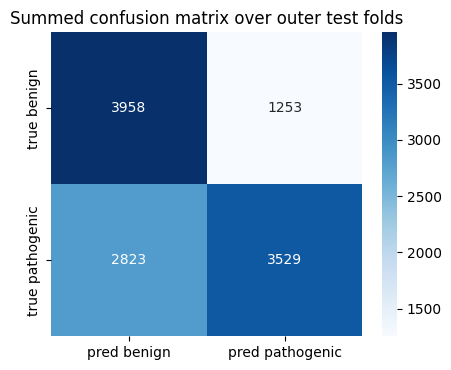

,threshold,roc_auc,pr_auc,precision,recall,accuracy,f1,tn,fp,fn,tp
fold,,,,,,,,,,,
0,0.463,0.534,0.429,0.578,0.180,0.662,0.275,1383,108,674,148
1,0.543,0.664,0.608,0.628,0.423,0.653,0.506,1099,243,560,411
2,0.514,0.665,0.671,0.679,0.684,0.668,0.682,720,389,380,824
3,0.509,0.588,0.769,0.799,0.693,0.643,0.742,299,299,527,1187
4,0.532,0.634,0.794,0.818,0.584,0.612,0.682,457,214,682,959


In [6]:
display(cls_summary.round(3))

cm = np.array(
    [
        [confusion_total["tn"], confusion_total["fp"]],
        [confusion_total["fn"], confusion_total["tp"]],
    ]
)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred benign", "pred pathogenic"],
    yticklabels=["true benign", "true pathogenic"],
    ax=ax,
)
ax.set_title("Summed confusion matrix over outer test folds")
fig.tight_layout()
plt.show()

display(
    fold_metrics[
        ["threshold", "roc_auc", "pr_auc", "precision", "recall", "accuracy", "f1", "tn", "fp", "fn", "tp"]
    ].round(3)
)


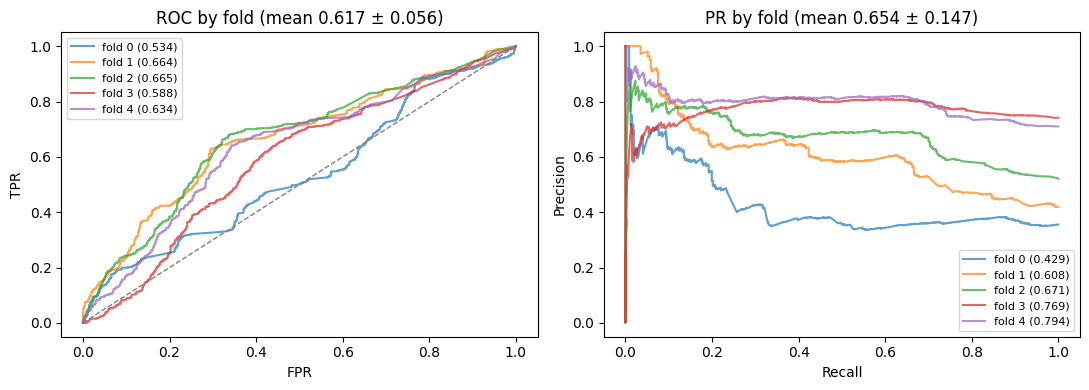

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mean_roc = fold_metrics["roc_auc"].mean()
std_roc = fold_metrics["roc_auc"].std()
mean_pr = fold_metrics["pr_auc"].mean()
std_pr = fold_metrics["pr_auc"].std()

for fold, part in oof.groupby("fold"):
    fpr, tpr, _ = roc_curve(part["y_true"], part["y_proba"])
    axes[0].plot(
        fpr,
        tpr,
        alpha=0.7,
        label=f"fold {fold} ({roc_auc_score(part['y_true'], part['y_proba']):.3f})",
    )
    prec, rec, _ = precision_recall_curve(part["y_true"], part["y_proba"])
    axes[1].plot(
        rec,
        prec,
        alpha=0.7,
        label=f"fold {fold} ({average_precision_score(part['y_true'], part['y_proba']):.3f})",
    )

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC by fold (mean {mean_roc:.3f} ± {std_roc:.3f})")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR by fold (mean {mean_pr:.3f} ± {std_pr:.3f})")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Feature importance across folds

Top 20 by mean across outer folds. Dummy names are `cat__{column}_{level}` after one-hot (sklearn models only).


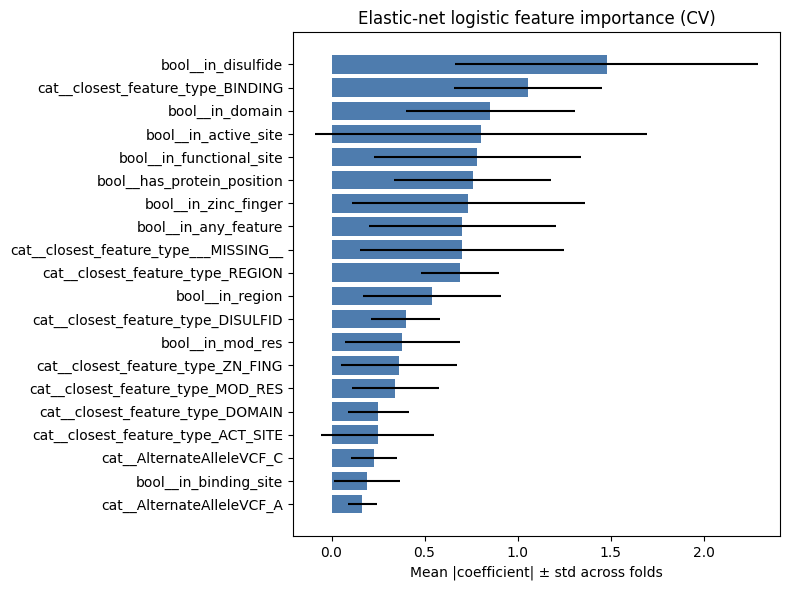

,mean,std
bool__in_disulfide,1.4785,0.8128
cat__closest_feature_type_BINDING,1.0553,0.3992
bool__in_domain,0.8532,0.4532
bool__in_active_site,0.8021,0.8910
bool__in_functional_site,0.7833,0.5566
bool__has_protein_position,0.7578,0.4214
bool__in_zinc_finger,0.7339,0.6265
bool__in_any_feature,0.7015,0.5023
cat__closest_feature_type___MISSING__,0.7014,0.5466
cat__closest_feature_type_REGION,0.6911,0.2106


In [8]:
top = importance_df.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top.index[::-1],
    top["mean"].iloc[::-1],
    xerr=top["std"].iloc[::-1],
    color="#3b6ea5",
    alpha=0.9,
)
ax.set_xlabel("Mean |coefficient| ± std across folds")
ax.set_title("Elastic-net logistic feature importance (CV)")
fig.tight_layout()
plt.show()

top[["mean", "std"]].round(4)


## Persist fold predictions

Headline metrics are mean±std across outer folds, not pooled OOF ROC. Compare these tables to `xgb_cv_fold_metrics.csv` on the same folds.


In [9]:
oof_path = MODELS_DIR / "logistic_cv_oof_predictions.parquet"
metrics_path = MODELS_DIR / "logistic_cv_fold_metrics.csv"
tuning_path = MODELS_DIR / "logistic_cv_tuning_log.csv"
oof.to_parquet(oof_path, index=False)
fold_metrics.to_csv(metrics_path)
tuning_log.to_csv(tuning_path, index=False)
print("Saved", oof_path)
print("Saved", metrics_path)
print("Saved", tuning_path)
fold_metrics.round(3)


Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/logistic_cv_oof_predictions.parquet
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/logistic_cv_fold_metrics.csv
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/logistic_cv_tuning_log.csv


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,tn,fp,fn,tp,param_l1_ratio,param_C
fold,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.644,None,0.463,0.534,0.429,0.662,0.578,0.180,0.275,1383,108,674,148,1.0,10.00
1,9250,2313,26,0.604,None,0.543,0.664,0.608,0.653,0.628,0.423,0.506,1099,243,560,411,1.0,10.00
2,9250,2313,31,0.610,None,0.514,0.665,0.671,0.668,0.679,0.684,0.682,720,389,380,824,0.0,1.00
3,9251,2312,30,0.661,None,0.509,0.588,0.769,0.643,0.799,0.693,0.742,299,299,527,1187,0.0,0.01
4,9251,2312,31,0.641,None,0.532,0.634,0.794,0.612,0.818,0.584,0.682,457,214,682,959,1.0,0.10


## Conclusion — honest performance KPIs

Gene-grouped **nested** CV on held-out genes (outer mean ± std).
Report these numbers next to XGBoost; do not pick a winner from outer-test scores and then quote only that winner.

**Primary (threshold-free):** ROC-AUC, PR-AUC.  
**Operating point:** precision / recall / accuracy / F1 at the inner-chosen **Youden** cutoff.


In [10]:
def _mean_std(series: pd.Series) -> str:
    return f"{series.mean():.3f} ± {series.std():.3f}"


print(f"Estimator: {ESTIMATOR}")
print(f"Threshold method: {THRESHOLD_METHOD}")
print(f"ROC-AUC     = {_mean_std(fold_metrics['roc_auc'])}")
print(f"PR-AUC      = {_mean_std(fold_metrics['pr_auc'])}")
print(f"Precision   = {_mean_std(fold_metrics['precision'])}")
print(f"Recall      = {_mean_std(fold_metrics['recall'])}")
print(f"Accuracy    = {_mean_std(fold_metrics['accuracy'])}")
print(f"F1          = {_mean_std(fold_metrics['f1'])}")
print(f"Threshold   = {_mean_std(fold_metrics['threshold'])}")


Estimator: logistic
Threshold method: youden
ROC-AUC     = 0.617 ± 0.056
PR-AUC      = 0.654 ± 0.147
Precision   = 0.700 ± 0.105
Recall      = 0.513 ± 0.215
Accuracy    = 0.647 ± 0.022
F1          = 0.577 ± 0.191
Threshold   = 0.512 ± 0.030


### Notes

- Same `cv_folds.parquet` / seed as `cv_xgboost.ipynb`.
- Stage 2 (`notebooks/modeling/final/`) stays XGBoost until a baseline clearly wins on these outer-fold KPIs.
